In [7]:
import numpy as np
import pandas as pd

In [8]:
df=pd.read_csv("/content/Titanic_dataset.csv")


In [9]:
print(df.head(10))


   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0         0       3    male  22.0      1      0   7.2500        S   Third   
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
4         0       3    male  35.0      0      0   8.0500        S   Third   
5         0       3    male   NaN      0      0   8.4583        Q   Third   
6         0       1    male  54.0      0      0  51.8625        S   First   
7         0       3    male   2.0      3      1  21.0750        S   Third   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes

In [10]:
print(df.tail(10))


     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
881         0       3    male  33.0      0      0   7.8958        S   Third   
882         0       3  female  22.0      0      0  10.5167        S   Third   
883         0       2    male  28.0      0      0  10.5000        S  Second   
884         0       3    male  25.0      0      0   7.0500        S   Third   
885         0       3  female  39.0      0      5  29.1250        Q   Third   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_male deck  embark_town alive  alone  
881    man        True  NaN  Southampton    no   True  
882  woman       F

In [11]:
print(df.shape)

(891, 15)


In [12]:
print(df.columns)
print(df.isnull().sum())
df['age'].fillna(df['age'].mean(),inplace=True)
print(df.isnull().sum())
df.dropna(inplace=True)
print(df.isnull().sum())
print(df[df['age']>30])
print(df[df['sex']=='female'])
print(df.groupby('sex')['survived'].mean()*100)
df_sorted=df.sort_values(by='age',ascending=True)
print(df_sorted.head(20))
df['Family_size']=df['sibsp']+df['parch']
print(df.head(5))
print(df['fare'].max())
print(df['fare'].min())
print(df['fare'].mean())
print(df['fare'].median())

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town

/tmp/ipykernel_1090/1278125836.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(),inplace=True)


In [13]:
df.to_csv('cleaned_titanic_dataset.csv')


In [14]:
#visualization

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
# df=pd.read_csv('/content/cleaned_titanic_dataset.csv')

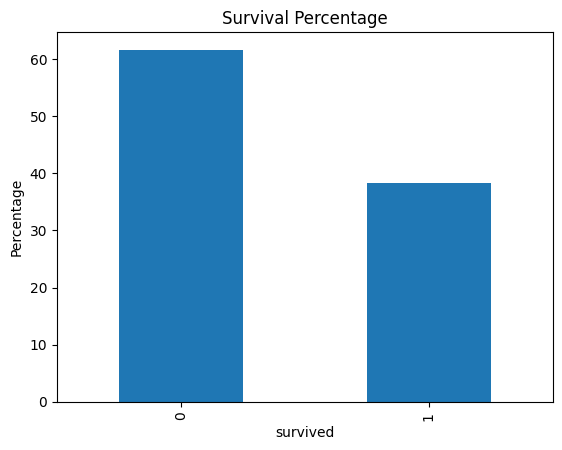

In [47]:
#Survival Rate
survival_rate = df['survived'].value_counts(normalize=True)*100
# print(survival_rate)
survival_rate.plot(kind='bar')
plt.title('Survival Percentage')
plt.ylabel('Percentage')
plt.show()

In [18]:
#Survival rate by gender


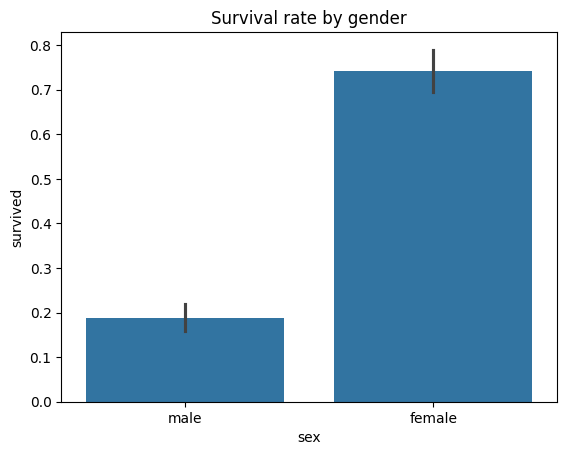

In [19]:
sns.barplot(x='sex',y='survived',data=df)
plt.title("Survival rate by gender")
plt.show()

In [20]:
#survival rate by gender :more female survived than male


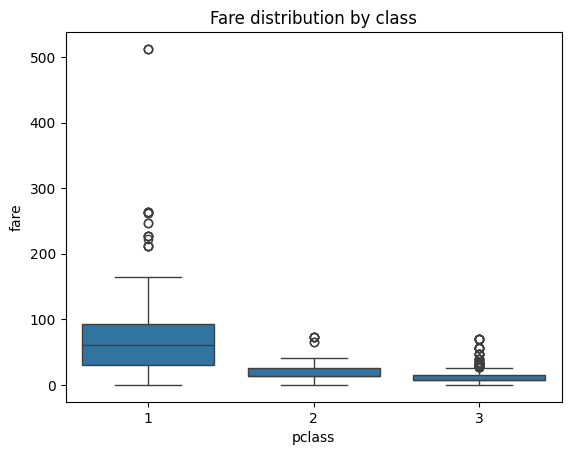

In [21]:
sns.boxplot(x='pclass',y='fare',data=df)
plt.title("Fare distribution by class")
plt.show()

In [22]:
# Class 1 people paid more fare


In [23]:
# df.describe()


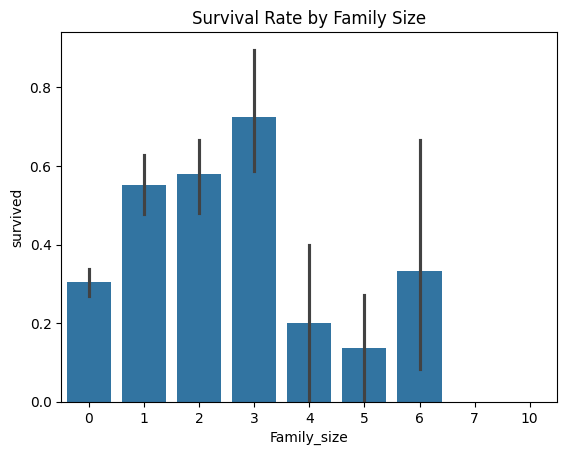

In [24]:
df['Family_size']=df['sibsp']+df['parch']
sns.barplot(x='Family_size',y='survived',data=df)
plt.title('Survival Rate by Family Size')
plt.show()

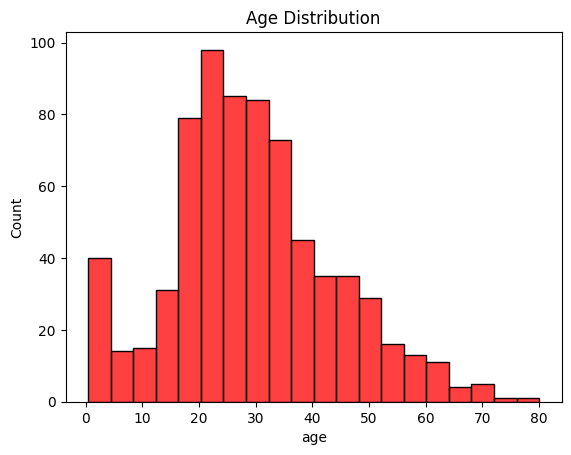

In [25]:
sns.histplot(df['age'],color='red')
plt.title('Age Distribution')
plt.show()


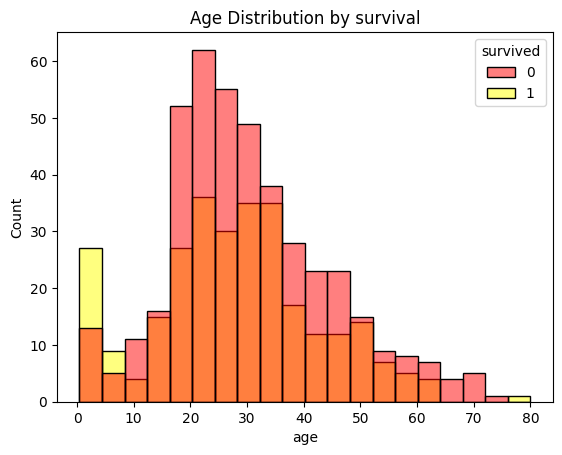

In [26]:
sns.histplot(data=df,x="age",hue="survived",palette=['red','yellow'])
plt.title('Age Distribution by survival')
plt.show()

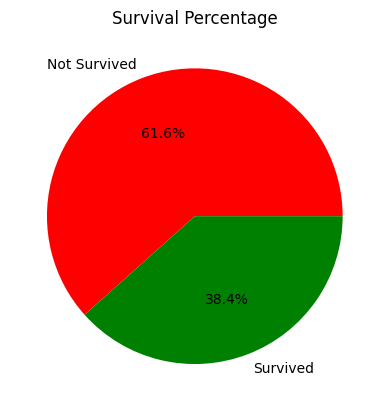

In [27]:
survival=df["survived"].value_counts()
plt.pie(survival,labels=["Not Survived","Survived"],autopct="%1.1f%%",colors=["Red","Green"])
plt.title('Survival Percentage')
plt.show()

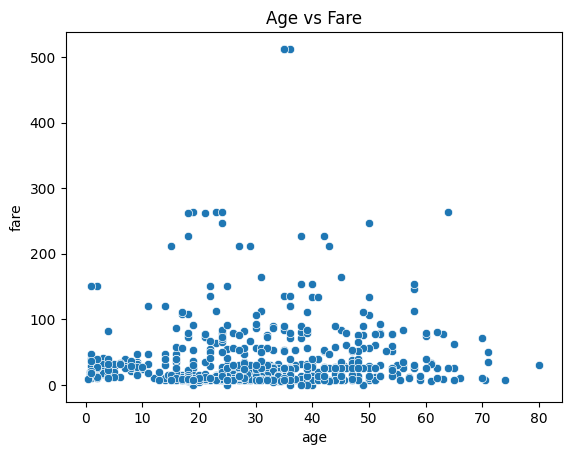

In [28]:
sns.scatterplot(x='age',y='fare',data=df)
plt.title('Age vs Fare')
plt.show()

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [30]:
df['embarked'].fillna("S",inplace=True)


/tmp/ipykernel_1090/874503472.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embarked'].fillna("S",inplace=True)


In [31]:
df["deck"].fillna("Unknown",inplace=True)


/tmp/ipykernel_1090/3525532290.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["deck"].fillna("Unknown",inplace=True)


In [32]:
df.drop(["class","who","adult_male","deck","embark_town","alive"],axis=1,inplace=True)


In [33]:
df["sex"]=df["sex"].map({"male":0,"female":1})


In [34]:
df["embarked"]=df["embarked"].map({"S":0,"C":1,"Q":2})


In [35]:
df["alone"]=df["alone"].map({True:1,False:0})


In [36]:
df.fillna(0, inplace=True)


In [37]:
x=df.drop(["survived"],axis=1)
y=df["survived"]

In [38]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [44]:
# age_mean_train = x_train['age'].mean()
# x_train.loc[:, 'age'] = x_train['age'].fillna(age_mean_train)
# x_test.loc[:, 'age'] = x_test['age'].fillna(age_mean_train)
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [40]:
y_pred=model.predict(x_test)


In [41]:
print("Accuracy:",accuracy_score(y_test,y_pred)*100)


Accuracy: 79.3296089385475


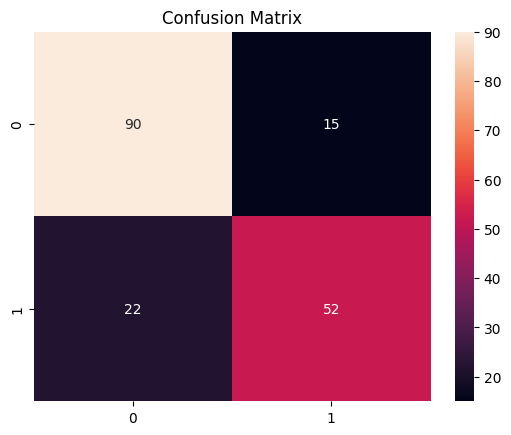

In [42]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.show()